# **Projet 2** : Analyse des systemes éducatifs

In [1]:
import pandas as pd
import numpy as np

In [91]:
import scipy.stats as st

In [2]:
import matplotlib as mpl

In [3]:
import seaborn as sb

In [4]:
from IPython.display import display, HTML


# **EXERCICE 1**

## Import des **données**

In [5]:
Ed_Data = pd.read_csv('EdStatsData.csv')

In [6]:
Ed_statcountS = pd.read_csv('EdStatsCountry-Series.csv')

In [7]:
Ed_statcount = pd.read_csv('EdStatsCountry.csv')
Ed_statfoot = pd.read_csv('EdStatsFootNote.csv')
Ed_statseries = pd.read_csv('EdStatsSeries.csv')

## Montrer les 5 premières lignes de chaque set

In [64]:
Ed_Data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
Ed_statcountS.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


In [14]:
Ed_statcount.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


In [15]:
Ed_statfoot.head()

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


In [16]:
Ed_statseries.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Collecte d'informations**

## Ed_Data

In [18]:
Ed_Data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Chaque ligne représente chaque indicateur pour chaque pays 

In [20]:
Ed_Data.shape

(886930, 70)

#Il y a 886930 lignes et 70 collones

In [22]:
Ed_Data.duplicated(keep=False).count


<bound method Series.count of 0         False
1         False
2         False
3         False
4         False
          ...  
886925    False
886926    False
886927    False
886928    False
886929    False
Length: 886930, dtype: bool>

In [23]:
Ed_Data.duplicated().sum()

0

In [24]:
Ed_Data.duplicated(subset=['Indicator Code']).sum()

883265

#Il n'y a aucune ligne doublon

In [26]:
Ed_Data.isnull().sum()

Country Name           0
Country Code           0
Indicator Name         0
Indicator Code         0
1970              814642
                   ...  
2085              835494
2090              835494
2095              835494
2100              835494
Unnamed: 69       886930
Length: 70, dtype: int64

In [16]:
prop_null = Ed_Data.isnull().mean()

In [399]:
prop_null

Country Name      0.000000
Country Code      0.000000
Indicator Name    0.000000
Indicator Code    0.000000
1970              0.918496
1971              0.959933
1972              0.959840
1973              0.959924
1974              0.959715
1975              0.901564
1976              0.957738
1977              0.957636
1978              0.957634
1979              0.958498
1980              0.899516
1981              0.956280
1982              0.957707
1983              0.956637
1984              0.956472
1985              0.898193
1986              0.955609
1987              0.956433
1988              0.956533
1989              0.957674
1990              0.859735
1991              0.916073
1992              0.914826
1993              0.914545
1994              0.912663
1995              0.851892
1996              0.913401
1997              0.917183
1998              0.904261
1999              0.866011
2000              0.800801
2001              0.860745
2002              0.859961
2

In [8]:
Ed_Data1 = Ed_Data.dropna(axis=1, how="all")

In [20]:
Ed_Data1.shape

(886930, 69)

In [ ]:
Ed_Data1['1970'].describe()

In [123]:
Ed_Data1.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,8.912200e+04,3.877700e+04,3.751100e+04,3.846000e+04,3.860600e+04,9.029600e+04,3.937200e+04,3.864100e+04,3.855200e+04,3.754000e+04,1.244050e+05,7.443700e+04,7.554300e+04,7.579300e+04,7.746200e+04,1.313610e+05,7.680700e+04,7.345300e+04,8.491400e+04,1.188390e+05,1.766760e+05,1.235090e+05,1.242050e+05,1.303630e+05,1.288140e+05,1.841080e+05,1.403120e+05,1.372720e+05,1.343870e+05,1.421080e+05,2.424420e+05,1.460120e+05,1.472640e+05,1.375090e+05,1.137890e+05,1.310580e+05,1.646000e+04,143.000000,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,3.283898e+09,7.664969e+09,7.913722e+09,7.856908e+09,8.118002e+09,3.622763e+09,9.156550e+09,1.014901e+10,1.104709e+10,1.195436e+10,9.084424e+09,1.571674e+10,1.604668e+10,1.643532e+10,1.684022e+10,1.052543e+10,1.874630e+10,2.027385e+10,1.794678e+10,1.331558e+10,9.423384e+09,1.384867e+10,1.428299e+10,1.449393e+10,1.589729e+10,1.188637e+10,1.684674e+10,1.872300e+10,2.029794e+10,1.894907e+10,1.189592e+10,2.117911e+10,2.176323e+10,2.425332e+10,2.678449e+10,2.353720e+10,1.934411e+11,2.160839,5.780697e+02,6.054774e+02,6.315916e+02,6.556516e+02,6.751516e+02,6.911287e+02,7.040640e+02,7.145788e+02,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,1.780774e+11,2.744142e+11,2.790549e+11,2.823809e+11,2.940635e+11,2.002929e+11,3.264675e+11,3.535351e+11,3.804257e+11,4.014873e+11,3.665667e+11,4.881357e+11,5.012055e+11,5.121962e+11,5.292982e+11,4.285218e+11,5.812586e+11,6.142357e+11,5.859148e+11,5.153472e+11,4.442374e+11,5.449242e+11,5.622886e+11,5.803607e+11,6.278337e+11,5.576181e+11,6.851484e+11,7.465688e+11,7.944132e+11,7.623650e+11,6.218710e+11,8.555853e+11,8.833955e+11,9.513016e+11,1.023180e+12,9.732465e+11,2.839188e+12,0.810584,1.475072e+04,1.577305e+04,1.678556e+04,1.778666e+04,1.874408e+04,1.965409e+04,2.052941e+04,2.136851e+04,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,-1.404240e+00,-1.478345e+00,-2.358765e+00,-2.867273e+00,-2.800548e+00,-2.216315e+00,-1.556722e+00,-1.410886e+00,-1.425202e+00,-1.562425e+00,-1.803750e+00,-5.814339e+00,-5.089333e+00,-6.184857e+00,-4.792691e+00,-2.697722e+00,-3.820174e+00,-2.517245e+00,-6.086200e+04,-6.526000e+04,-6.759300e+04,-6.973700e+04,-9.214300e+04,-1.111860e+05,-1.262600e+05,-1.347240e+05,-3.708940e+05,-3.882170e+05,-4.088540e+05,-4.561240e+05,-4.969050e+05,-5.709940e+05,-6.049930e+05,-6.157480e+05,-8.900000e+01,-2.467847e+00,-1.797539e+00,1.000000,-1.870000e+00,-2.000000e+00,-2.110000e+00,-2.150000e+00,-2.140000e+00,-2.090000e+00,-1.980000e+00,-1.830000e+00,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,1.770000e+00,9.468690e+00,9.989330e+00,9.581825e+00,9.068048e+00,2.150000e+00,9.332923e+00,

In [125]:
for col in Ed_Data1.select_dtypes(include=['object', 'category']):
    print(f"\n--- {col} ---")
    print(Ed_Data1[col].value_counts())



--- Country Name ---
Country Name
Arab World               3665
Portugal                 3665
Micronesia, Fed. Sts.    3665
Moldova                  3665
Monaco                   3665
                         ... 
Equatorial Guinea        3665
Eritrea                  3665
Estonia                  3665
Ethiopia                 3665
Zimbabwe                 3665
Name: count, Length: 242, dtype: int64

--- Country Code ---
Country Code
ARB    3665
PRT    3665
FSM    3665
MDA    3665
MCO    3665
       ... 
GNQ    3665
ERI    3665
EST    3665
ETH    3665
ZWE    3665
Name: count, Length: 242, dtype: int64

--- Indicator Name ---
Indicator Name
Adjusted net enrolment rate, lower secondary, both sexes (%)                                       242
Population, ages 10-18, female                                                                     242
Population, ages 10-18, total                                                                      242
Population, ages 11-15, female            

In [70]:
Ed_Data1['Indicator Code'].value_counts()

Indicator Code
UIS.NERA.2              242
SP.POP.1018.FE.UN       242
SP.POP.1018.TO.UN       242
SP.POP.1115.FE.UN       242
SP.POP.1115.MA.UN       242
                       ... 
UIS.XPUBP.UK            242
UIS.XPUBP.2             242
UIS.XGOVEXP.IMF.2       242
UIS.XPUBP.4             242
SE.ADT.1524.LT.MA.ZS    242
Name: count, Length: 3665, dtype: int64

# Ed_StatcountS

In [72]:
Ed_statcountS.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


#Chaque ligne represente un set de données utilisées 

In [127]:
Ed_statcountS.shape

(613, 4)

In [129]:
Ed_statcountS.duplicated().sum()

0

#Il y a 0 doublon

In [ ]:
Ed_statcountS.isnull().sum()

In [131]:
Ed_statcountS.isnull().mean()

CountryCode    0.0
SeriesCode     0.0
DESCRIPTION    0.0
Unnamed: 3     1.0
dtype: float64

In [9]:
Ed_statcountS1 = Ed_statcountS.dropna(axis=1, how="all")

In [ ]:
Ed_statcountS1.shape

#Il n'y a aucune colonne numérique

In [ ]:
for col in Ed_statcountS1.select_dtypes(include=['object', 'category']):
    print(f"\n--- {col} ---")
    print(Ed_statcountS1[col].value_counts())

## Ed_statcount

In [ ]:
Ed_statcount.head()

In [ ]:
Ed_statcount.shape

In [133]:
Ed_statcount.duplicated().sum()

0

#Aucun doublon

In [ ]:
Ed_statcount.isnull().mean()

In [10]:
Ed_statcount2 = Ed_statcount.dropna(axis=1, how="all")

In [78]:
Ed_statcount2.shape

(241, 31)

#Aucune colonne numérique

In [25]:
for col in Ed_statcount2.select_dtypes(include=['object', 'category']):
    print(f"\n--- {col} ---")
    print(Ed_statcount2[col].value_counts())


--- Country Code ---
Country Code
ABW    1
LCA    1
MRT    1
MUS    1
MWI    1
      ..
GRL    1
GTM    1
GUM    1
GUY    1
ZWE    1
Name: count, Length: 241, dtype: int64

--- Short Name ---
Short Name
Aruba         1
St. Lucia     1
Mauritania    1
Mauritius     1
Malawi        1
             ..
Greenland     1
Guatemala     1
Guam          1
Guyana        1
Zimbabwe      1
Name: count, Length: 241, dtype: int64

--- Table Name ---
Table Name
Aruba         1
St. Lucia     1
Mauritania    1
Mauritius     1
Malawi        1
             ..
Greenland     1
Guatemala     1
Guam          1
Guyana        1
Zimbabwe      1
Name: count, Length: 241, dtype: int64

--- Long Name ---
Long Name
Aruba                              1
St. Lucia                          1
Islamic Republic of Mauritania     1
Republic of Mauritius              1
Republic of Malawi                 1
                                  ..
Greenland                          1
Republic of Guatemala              1
Guam      

## Ed_statfoot

In [ ]:
Ed_statfoot.head()

#Chaque ligne correspond au set de données de chaque année pour chaque pays

In [ ]:
Ed_statfoot.shape

In [135]:
Ed_statfoot.duplicated().sum()

0

#Aucun doublon

In [341]:
Ed_statfoot.isnull().mean()

CountryCode    0.0
SeriesCode     0.0
Year           0.0
DESCRIPTION    0.0
Unnamed: 4     1.0
dtype: float64

In [11]:
Ed_statfoot1 = Ed_statfoot.dropna(axis=1, how="all")

In [ ]:
Ed_statfoot1.shape

#Pas de colonne numérique 

In [ ]:
for col in Ed_statfoot1.select_dtypes(include=['object', 'category']):
    print(f"\n--- {col} ---")
    print(Ed_statfoot1[col].value_counts())

## Ed_statseries

#Chaque ligne represente un indicateur différent 

In [ ]:
Ed_statseries.shape

In [137]:
Ed_statseries.duplicated().sum()

0

#Aucun doublon

In [ ]:
Ed_statseries.isnull().mean()

In [12]:
Ed_statseries1 = Ed_statseries.dropna(axis=1, how="all")

In [139]:
Ed_statseries1.shape

(3665, 15)

#Pas de colonne numérique

In [141]:
for col in Ed_statseries1.select_dtypes(include=['object', 'category']):
    print(f"\n--- {col} ---")
    print(Ed_statseries1[col].value_counts())


--- Series Code ---
Series Code
BAR.NOED.1519.FE.ZS            1
SP.POP.0710.FE.UN              1
SP.POP.0710.TO.UN              1
SP.POP.0711.FE.UN              1
SP.POP.0711.MA.UN              1
                              ..
LO.PASEC.MAT5.LO.MA            1
LO.PASEC.MAT5.MA               1
LO.PASEC.REA.2                 1
LO.PASEC.REA.2.FE              1
XGDP.56.FSGOV.FDINSTADM.FFD    1
Name: count, Length: 3665, dtype: int64

--- Topic ---
Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                            

# **Nettoyage des bases de données** 

## Commençons par supprimer les faux pays du dataframe Country

In [86]:
Ed_statcount2.shape

(241, 31)

In [ ]:
Ed_statcount2

In [ ]:
Ed_statcount2.shape

In [13]:
Faux_Ploc2 = Ed_statcount2.loc[(Ed_statcount2['Currency Unit'].isna()) & (Ed_statcount2['Special Notes'].notnull()) , :]

In [14]:
Faux_Ploc2 = Faux_Ploc2.rename(columns={'Country Code': 'CountryCode'})

In [15]:
Faux_Ploc2

,CountryCode,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
5,ARB,Arab World,Arab World,Arab World,1A,NaN,Arab World aggregate. Arab World is composed o...,NaN,NaN,1A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,EAP,East Asia & Pacific (developing only),East Asia & Pacific,East Asia & Pacific (developing only),4E,NaN,East Asia and Pacific regional aggregate (does...,NaN,NaN,4E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,EAS,East Asia & Pacific (all income levels),East Asia & Pacific (all income levels),East Asia & Pacific (all income levels),Z4,NaN,East Asia and Pacific regional aggregate (incl...,NaN,NaN,Z4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,ECA,Europe & Central Asia (developing only),Europe & Central Asia,Europe & Central Asia (developing only),7E,NaN,Europe and Central Asia regional aggregate (do...,NaN,NaN,7E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,ECS,Europe & Central Asia (all income levels),Europe & Central Asia (all income levels),Europe & Central Asia (all income levels),Z7,NaN,Europe and Central Asia regional aggregate (in...,NaN,NaN,Z7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,EMU,Euro area,Euro area,Euro area,XC,NaN,Euro area aggregate.,NaN,NaN,XC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,EUU,European Union,European Union,European Union,EU,NaN,European Union aggregate.,NaN,NaN,EU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,HIC,High income,High income,High income,XD,NaN,High income group aggregate. High-income econo...,NaN,NaN,XD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,HPC,Heavily indebted poor countries (HIPC),Heavily indebted poor countries (HIPC),Heavily indebted poor countries (HIPC),XE,NaN,Heavily indebted poor countries aggregate.,NaN,NaN,XE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,LAC,Latin America & Caribbean (developing only),Latin America & Caribbean,Latin America & Caribbean (developing only),XJ,NaN,Latin America and Caribbean regional aggregate...,NaN,NaN,XJ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
EDc3 = Ed_statcount2[ ~Ed_statcount2['Country Code'].isin(Faux_Ploc2['CountryCode']) ]

In [143]:
EDc3

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,2000,NaN,Value added at basic prices (VAB),NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,"IMF Balance of Payments Manual, 6th edition.",NaN,Special trade system,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,2002,NaN,Value added at producer prices (VAP),IBRD,NaN,Country uses the 1993 System of National Accou...,1991–96,2005,"IMF Balance of Payments Manual, 6th edition.",Actual,Special trade system,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,Original chained constant price data are resca...,1996.0,Value added at basic prices (VAB),IBRD,NaN,Country uses the 1993 System of National Accou...,NaN,Rolling,"IMF Balance of Payments Manual, 6th edition.",Actual,General trade system,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,1990,NaN,NaN,NaN,NaN,Country uses the 1968 System of National Accou...,NaN,NaN,NaN,NaN,Special trade system,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,2008,NaN,Value added at basic prices (VAB),IDA,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,NaN,NaN,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN
212,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,2007,NaN,Value added at producer prices (VAP),IDA,NaN,Country uses the 1993 System of National Accou...,1990–96,2005,"IMF Balance of Payments Manual, 6th edition.",Actual,Special trade system,Budgetary central government,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.0,2012.0,2005
213,ZAF,South Africa,South Af

In [17]:
EDc3 = EDc3.reset_index()

In [ ]:
EDc3

In [18]:
EDc3 = EDc3.drop('index', axis=1)

In [41]:
EDc3

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,...,NaN,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN
212,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,...,Budgetary central government,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.0,2012.0,2005
213,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey (DHS), 2003; Wor...","Expenditure survey/budget survey (ES/BS), 2010",NaN,2007,2010.0,2012.0,2000
214,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data have rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,General Data Dissemination System (GDDS),2010,"Demographic and Health Survey (DHS), 2013","Integrated household survey (IHS), 2010",NaN,2010. Population and Housing Census.,NaN,2011.0,2002


## **Maintenant supprimons les faux pays des autres DF**

# Ed_statcountS1


## Methode 1

In [43]:
Ed_statcountS1[ ~Ed_statcountS1["CountryCode"].isin(Faux_Ploc2['CountryCode']) ] 

,CountryCode,SeriesCode,DESCRIPTION
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...
...,...,...,...
608,ZAF,SP.POP.GROW,"Data sources : Statistics South Africa, United..."
609,ZMB,SP.POP.GROW,Data sources: United Nations World Population ...
610,ZMB,SP.POP.TOTL,Data sources : United Nations World Population...
611,ZWE,SP.POP.TOTL,Data sources : United Nations World Population...


In [151]:
Ed_statcountS1

,CountryCode,SeriesCode,DESCRIPTION
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...
...,...,...,...
608,ZAF,SP.POP.GROW,"Data sources : Statistics South Africa, United..."
609,ZMB,SP.POP.GROW,Data sources: United Nations World Population ...
610,ZMB,SP.POP.TOTL,Data sources : United Nations World Population...
611,ZWE,SP.POP.TOTL,Data sources : United Nations World Population...


In [193]:
len(Ed_statcountS1['CountryCode'].unique())

211

In [221]:
Ed_statcountS1['CountryCode']

0      ABW
1      ABW
2      AFG
3      AFG
4      AFG
      ... 
608    ZAF
609    ZMB
610    ZMB
611    ZWE
612    ZWE
Name: CountryCode, Length: 613, dtype: object

In [207]:
len(EDc3['Country Code'].unique())

216

In [19]:
diff_statcounts_edc = EDc3[~EDc3['Country Code'].isin(Ed_statcountS1['CountryCode'])]

In [239]:
diff_statcounts_edc

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
46,CUW,Curaçao,Curaçao,Curaçao,CW,Netherlands Antilles guilder,NaN,Latin America & Caribbean,High income: nonOECD,CW,NaN,NaN,NaN,NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,MAF,St. Martin (French part),St. Martin (French part),St. Martin (French part),MF,Euro,NaN,Latin America & Caribbean,High income: nonOECD,MF,NaN,NaN,NaN,NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,NRU,Nauru,Nauru,Nauru,NR,NaN,NaN,NaN,NaN,NR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
177,SSD,South Sudan,South Sudan,Republic of South Sudan,SS,South Sudanese Pound,South Sudan declared its independence on July ...,Sub-Saharan Africa,Lower middle income,SS,2009,NaN,NaN,IDA,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008,NaN,"Expenditure survey/budget survey (ES/BS), 2009",NaN,NaN,NaN,NaN,NaN
184,SXM,Sint Maarten (Dutch part),Sint Maarten (Dutch part),Sint Maarten (Dutch part),SX,Netherlands Antilles guilder,NaN,Latin America & Caribbean,High income: nonOECD,SX,NaN,NaN,NaN,NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,NaN,NaN,Yes,NaN,NaN,NaN,NaN


#Ce dataframe contient 211 pays et aucun faux pays cependant il manque 5 vrai pays qui n'y figurent pas

## Methode 2

# Ed_Data

## Methode 1 

In [ ]:
Faux_Ploc2

In [24]:
Ed_Data2 = Ed_Data1[ ~Ed_Data1['Country Code'].isin(Faux_Ploc2['CountryCode']) ] 

In [159]:
Ed_Data1[Ed_Data1['Country Code'].isin(Ed_statcountS1['CountryCode'])]

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.260189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.059870,NaN,NaN,NaN,NaN,NaN,47.436790,50.627232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.431810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.223100,NaN,NaN,NaN,NaN,NaN,34.073261,37.641541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379130,NaN,NaN,NaN,NaN,NaN,0.567060,0.598370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.420429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.152851,NaN,NaN,NaN,NaN,NaN,60.087059,62.906952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91629,Afghanistan,AFG,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47631.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38800.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166679.00000,NaN,NaN,199464.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.021851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.411362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.93070,NaN,NaN,90.428120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.812241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.353439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.12456,NaN,NaN,93.188350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.903920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.02828,NaN,NaN,1.063890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [28]:
Ed_Data2

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91629,Afghanistan,AFG,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [319]:
#Suppression du faux pays étrange caché au sein de cette seule base de données : VGB

In [26]:
Ed_Data2 = Ed_Data2[Ed_Data2['Country Code'] != 'VGB']

## Methode 2

In [27]:
Ed_DataJ = pd.merge(Ed_Data1, EDc3, on= 'Country Code' , how='inner')

In [197]:
Ed_DataJ

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.260189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.059870,NaN,NaN,NaN,NaN,NaN,47.436790,50.627232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
1,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.431810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.223100,NaN,NaN,NaN,NaN,NaN,34.073261,37.641541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
2,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379130,NaN,NaN,NaN,NaN,NaN,0.567060,0.598370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
3,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.420429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.152851,NaN,NaN,NaN,NaN,NaN,60.087059,62.906952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanista

In [183]:
pd.merge(Ed_Data1, Ed_statcountS1[['CountryCode']], left_on='Country Code' , right_on='CountryCode' , how='inner').drop_duplicates()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,CountryCode
0,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.260189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.059870,NaN,NaN,NaN,NaN,NaN,47.436790,50.627232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
8,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.431810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.223100,NaN,NaN,NaN,NaN,NaN,34.073261,37.641541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
16,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379130,NaN,NaN,NaN,NaN,NaN,0.567060,0.598370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
24,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.420429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.152851,NaN,NaN,NaN,NaN,NaN,60.087059,62.906952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
32,Afghanistan,AFG,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246635,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47631.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38800.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166679.00000,NaN,NaN,199464.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE
2246637,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.021851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.411362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.93070,NaN,NaN,90.428120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE
2246639,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.812241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.353439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.12456,NaN,NaN,93.188350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZWE
2246641,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.903920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.977340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.02828,NaN,NaN,1.063890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

# Ed_statfoot 

## Methode 1 

In [ ]:
Ed_statfoot1

In [28]:
Ed_statfoot2 = Ed_statfoot1[ ~Ed_statfoot1['CountryCode'].isin(Faux_Ploc2['CountryCode']) ] 

In [29]:
Ed_statfoot2 = Ed_statfoot2[Ed_statfoot2['CountryCode'] != 'VGB']

In [30]:
Ed_statfoot2

,CountryCode,SeriesCode,Year,DESCRIPTION
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.
...,...,...,...,...
643633,ZWE,SH.DYN.MORT,YR2007,Uncertainty bound is 91.6 - 109.3
643634,ZWE,SH.DYN.MORT,YR2014,Uncertainty bound is 54.3 - 76
643635,ZWE,SH.DYN.MORT,YR2015,Uncertainty bound is 48.3 - 73.3
643636,ZWE,SH.DYN.MORT,YR2017,5-year average value between 0s and 5s


## Methode 2

In [33]:
Ed_statfootJ = pd.merge(Ed_statfoot1, EDc3, left_on='CountryCode', right_on='Country Code')

In [33]:
Ed_statfootJ

,CountryCode,SeriesCode,Year,DESCRIPTION,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518104,ZWE,SH.DYN.MORT,YR2007,Uncertainty bound is 91.6 - 109.3,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,...,Consolidated central government,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.0,2002
518105,ZWE,SH.DYN.MORT,YR2014,Uncertainty bound is 54.3 - 76,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,...,Consolidated central government,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.0,2002
518106,ZWE,SH.DYN.MORT,YR2015,Uncertainty bound is 48.3 - 73.3,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,...,Consolidated central government,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.0,2002
518107,ZWE,SH.DYN.MORT,YR2017,5-year average value between 0s and 5s,ZWE,Zimbabwe,Zimbabwe,Republic of Zimbabwe,ZW,U.S. dollar,...,Consolidated central government,General Data Dissemination System (GDDS),2012,"Demographic and Health Survey (DHS), 2010/11","Integrated household survey (IHS), 2011/12",NaN,NaN,NaN,2012.0,2002


# **Exercice 2**

## étape 1


#C'est la base de donnees Ed_statSeries qui nous donne la liste complète de chaque indicateur. 
La colonne 'Topic' semble correspondre à la categorie métier


In [112]:
Ed_statseries1

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,Secondary,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN


In [114]:
Ed_statseries1['Topic'].value_counts()

Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

In [35]:
Indic_mark = Ed_statseries1.loc[
  (Ed_statseries1['Topic'] == 'Secondary') 
| (Ed_statseries1['Topic'] == 'Tertiary')
| (Ed_statseries1['Topic'] == 'Economic Policy & Debt: Purchasing power parity') 
| (Ed_statseries1['Topic'] == 'Economic Policy & Debt: National accounts: US$ at current prices: Aggregate indicators')
| (Ed_statseries1['Topic'] == 'Economic Policy & Debt: National accounts: US$ at constant 2010 prices: Aggregate indicators')
| (Ed_statseries1['Topic'] == 'Economic Policy & Debt: National accounts: Atlas GNI & GNI per capita')
| (Ed_statseries1['Topic'] == 'Infrastructure: Communications')
| (Ed_statseries1['Topic'] == 'Population') ]

In [59]:
Indic_mark

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
610,IT.CMP.PCMP.P2,Infrastructure: Communications,Personal computers (per 100 people),NaN,Personal computers are self-contained computer...,Annual,NaN,NaN,Weighted average,NaN,Restricted use: Please cite the International ...,"International Telecommunication Union, World T...",NaN,NaN,NaN
611,IT.NET.USER.P2,Infrastructure: Communications,Internet users (per 100 people),NaN,Internet users are individuals who have used t...,Annual,NaN,NaN,Weighted average,Operators have traditionally been the main sou...,Please cite the International Telecommunicatio...,"International Telecommunication Union, World T...",NaN,NaN,NaN
1658,NY.GDP.MKTP.CD,Economic Policy & Debt: National accounts: US$...,GDP (current US$),NaN,GDP at purchaser's prices is the sum of gross ...,Annual,NaN,NaN,Gap-filled total,"Gross domestic product (GDP), though widely tr...",NaN,"World Bank national accounts data, and OECD Na...",NaN,NaN,NaN
1659,NY.GDP.MKTP.KD,Economic Policy & Debt: National accounts: US$...,GDP (constant 2010 US$),NaN,GDP at purchaser's prices is the sum of gross ...,Annual,2010,NaN,Gap-filled total,Each industry's contribution to growth in the ...,NaN,"World Bank national accounts data, and OECD Na...",NaN,NaN,NaN
1660,NY.GDP.MKTP.PP.CD,Economic Policy & Debt: Purchasing power parity,"GDP, PPP (current international $)",NaN,PPP GDP is gross domestic product converted to...,Annual,NaN,NaN,Gap-filled total,NaN,NaN,"World Bank, International Comparison Program d...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,UIS.thDur.4.A.GPV,Tertiary,Theoretical duration of post-secondary non-ter...,NaN,Number of grades (years) in post-secondary edu...,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3553,UIS.TranRA.23.GPV.GPI,Secondary,Effective transition rate from primary to lowe...,NaN,The ratio of the female transition rate to the...,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3578,UIS.UAPP.23,Secondary,Under-age enrolment ratio in secondary educati...,NaN,Percentage of the secondary school age populat...,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3579,UIS.UAPP.23.F,Secondary,Under-age enrolment ratio in secondary educati...,NaN,Percentage of the female secondary school age ...,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN


#Il reste donc 8 catégories métier

#Filtrons ce dataset sur la base de nos 8 catégories métier


## Filtrage des autres dataset

#statfootnote 

In [36]:
Ed_statfoot9 = Ed_statfoot2[Ed_statfoot2['SeriesCode'].isin(Indic_mark['Series Code']) ]

In [120]:
Ed_statfoot9

,CountryCode,SeriesCode,Year,DESCRIPTION
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.
6,ABW,SE.SEC.ENRL.VO.FE,YR2005,Country estimation.
7,ABW,SE.SEC.ENRL.GC,YR2003,Country estimation.
12,ABW,SE.SEC.ENRL.VO.FE.ZS,YR2002,Country estimation.
14,ABW,SE.SEC.ENRL.VO.FE.ZS,YR2007,Country estimation.
...,...,...,...,...
643587,ZWE,SE.TER.ENRR.MA,YR1992,Country Data
643588,ZWE,SE.TER.GRAD.FE.ZS,YR1981,Country Data
643619,ZWE,SE.SEC.ENRL.GC,YR1999,Country estimation.
643620,ZWE,SE.SEC.ENRL.GC.FE,YR1998,UIS estimation.


#statcountS

In [37]:
Ed_statcountS9 = Ed_statcountS1[Ed_statcountS1["SeriesCode"].isin(Indic_mark['Series Code']) ] 

In [38]:
Ed_statcountS9 = Ed_statcountS9.reset_index()


In [39]:
Ed_statcountS9 = Ed_statcountS9.drop('index', axis=1)


In [40]:
Ed_statcountS9

,CountryCode,SeriesCode,DESCRIPTION
0,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.
1,AFG,NY.GDP.MKTP.PP.KD,Estimates are based on regression.
2,AFG,NY.GNP.MKTP.PP.CD,Estimates are based on regression.
3,AFG,NY.GDP.MKTP.PP.CD,Estimates are based on regression.
4,AFG,NY.GDP.PCAP.PP.KD,Estimates are based on regression.
...,...,...,...
110,XKX,NY.GNP.MKTP.PP.CD,Estimates are based on regression.
111,XKX,NY.GDP.PCAP.PP.CD,Estimates are based on regression.
112,XKX,NY.GNP.PCAP.PP.CD,Estimates are based on regression.
113,XKX,NY.GDP.MKTP.PP.CD,Estimates are based on regression.


#Ed_StatsData

In [41]:
Ed_Data9 = Ed_Data2.loc[Ed_Data2["Indicator Code"].isin(Indic_mark['Series Code']) ]

In [91]:
Ed_Data9

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,7.05911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.260189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.059870,NaN,NaN,NaN,NaN,NaN,47.436790,50.627232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,2.53138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.431810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.223100,NaN,NaN,NaN,NaN,NaN,34.073261,37.641541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,0.22154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379130,NaN,NaN,NaN,NaN,NaN,0.567060,0.598370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,11.42652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.420429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.152851,NaN,NaN,NaN,NaN,NaN,60.087059,62.906952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91633,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.332621,32.417030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886357,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, gen...",UIS.NERT.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.898190,0.919770,0.904810,0.919870,0.917620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959140,0.963910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886358,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, mal...",UIS.NERT.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.261307,90.459709,92.427429,83.121017,77.620712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.689339,93.502541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886608,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.813420,0.870420,0.886320,0.814140,0.835250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510160,0.583580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886609,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.976710,1.005390,1.026590,0.947850,0.982680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.641460,0.723340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [42]:
Ed_Data99 = pd.merge(Ed_Data2, Indic_mark, left_on='Indicator Code', right_on='Series Code')

In [ ]:
Ed_Data99

## **Réduction périmètre du fichier DATA**

In [43]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100)

#Nous avons des valeurs d'indicateur pour des annees futures car cette base de donnees contient des valeurs projetées
calculées sur la base de probabilités

#Pour etudier les pays avec un fort potentiel de cliens et comment cela pourrait evoluer, nous allons nous concentrer sur une plage d'annéees, de 2000 à 2016

In [347]:
Ed_Data9.isnull().mean()

Country Name      0.000000
Country Code      0.000000
Indicator Name    0.000000
Indicator Code    0.000000
1970              0.933790
1971              0.880820
1972              0.882566
1973              0.882670
1974              0.882189
1975              0.886553
1976              0.880177
1977              0.877544
1978              0.878801
1979              0.880828
1980              0.882751
1981              0.880562
1982              0.883949
1983              0.878979
1984              0.879800
1985              0.879533
1986              0.877011
1987              0.879992
1988              0.880710
1989              0.884386
1990              0.632868
1991              0.633045
1992              0.631129
1993              0.626691
1994              0.622882
1995              0.626403
1996              0.628355
1997              0.638667
1998              0.602059
1999              0.481031
2000              0.472139
2001              0.462841
2002              0.452434
2

In [44]:
liste_1 = np.arange(1970, 2000, 1)

In [351]:
liste_1

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999])

In [353]:
liste_1.dtype

dtype('int32')

In [45]:
liste_2 = np.arange(2020, 2101, 5)

In [369]:
liste_2

array([2020, 2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070,
       2075, 2080, 2085, 2090, 2095, 2100])

In [46]:
liste_annee = np.concatenate((liste_1, liste_2))

In [373]:
liste_annee

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2020, 2025, 2030,
       2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085,
       2090, 2095, 2100])

In [47]:
liste_annee1 = liste_annee.astype(str)

In [53]:
liste_annee1

array(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985',
       '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993',
       '1994', '1995', '1996', '1997', '1998', '1999', '2020', '2025',
       '2030', '2035', '2040', '2045', '2050', '2055', '2060', '2065',
       '2070', '2075', '2080', '2085', '2090', '2095', '2100'],
      dtype='<U21')

In [379]:
liste_annee1.dtype

dtype('<U11')

In [48]:
goodYR = ~Ed_Data9.columns.isin(liste_annee1)

In [49]:
Ed_Data10 = Ed_Data9.loc[:, goodYR]

In [50]:
Ed_Data10 = Ed_Data10[Ed_Data10['Country Code'] != 'VGB']

In [51]:
Ed_Data10

,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.059870,NaN,NaN,NaN,NaN,NaN,47.436790,50.627232,NaN,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.223100,NaN,NaN,NaN,NaN,NaN,34.073261,37.641541,NaN,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379130,NaN,NaN,NaN,NaN,NaN,0.567060,0.598370,NaN,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.152851,NaN,NaN,NaN,NaN,NaN,60.087059,62.906952,NaN,NaN,NaN
91633,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.332621,32.417030,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886357,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, gen...",UIS.NERT.2.GPI,0.919770,0.904810,0.919870,0.917620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959140,0.963910,NaN,NaN,NaN,NaN
886358,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, mal...",UIS.NERT.2.M,90.459709,92.427429,83.121017,77.620712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.689339,93.502541,NaN,NaN,NaN,NaN
886608,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23,0.870420,0.886320,0.814140,0.835250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510160,0.583580,NaN,NaN,NaN,NaN
886609,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23.F,1.005390,1.026590,0.947850,0.982680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.641460,0.723340,NaN,NaN,NaN,NaN


In [52]:
Ed_Data10 = Ed_Data10.dropna(axis=1, how="all")

In [393]:
Ed_Data10.isnull().mean()

Country Name      0.000000
Country Code      0.000000
Indicator Name    0.000000
Indicator Code    0.000000
2000              0.472139
2001              0.462841
2002              0.452434
2003              0.456754
2004              0.441376
2005              0.442744
2006              0.453558
2007              0.449105
2008              0.440059
2009              0.436412
2010              0.438291
2011              0.429518
2012              0.430791
2013              0.428172
2014              0.541900
2015              0.642328
2016              0.942748
dtype: float64

#Mark veut voir comment le potentiel des pays pourrait evoluer, j'ai donc surement supprimer des années et indicateurs
en trop, en effet je me retrouve avec aucune année ne depassant de 2016

#2eme proportion : Pour chaque indicateur, calculez la proportion d’années avec des valeurs renseignées

In [53]:
good_year = np.arange(2000,2017,1)

In [54]:
good_years = good_year.astype(str)

In [55]:
good_years

array(['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016'], dtype='<U21')

In [56]:
pd.options.display.float_format = '{:.4f}'.format

In [57]:
prop_year_perindic = Ed_Data10.melt(
    id_vars=["Indicator Code", "Country Name", "Indicator Name", "Country Code"],
    value_vars=['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015','2016'] ,
    var_name="Année",
    value_name="Valeur"
)

In [64]:
prop_year_perindic.groupby("Indicator Code")["Valeur"].apply(lambda x: x.notnull().mean())

Indicator Code
IT.CMP.PCMP.P2       0.3355
IT.NET.USER.P2       0.9251
NY.GDP.MKTP.CD       0.9295
NY.GDP.MKTP.KD       0.9080
NY.GDP.MKTP.PP.CD    0.8704
                      ...  
UIS.TE_100000.56.F   0.4916
UIS.TE_100000.56.M   0.4916
UIS.UAPP.23          0.3510
UIS.UAPP.23.F        0.3461
UIS.UAPP.23.M        0.3445
Name: Valeur, Length: 623, dtype: float64

#1ère proportion : Pour chaque année, calculez la proportion d’indicateurs avec des valeurs renseignées (c’est-à-dire, non manquantes)

In [58]:
Ed_grp = Ed_Data10.melt(id_vars = 'Indicator Code',
                        value_vars=['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015','2016'],
                        var_name='année', value_name='valeur')

In [59]:
prop_indic_peryear = Ed_grp.groupby('année').apply(lambda x: x.notna().mean())
prop_indic_peryear

C:\Users\yacin\AppData\Local\Temp\ipykernel_14784\1203705708.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop_indic_peryear = Ed_grp.groupby('année').apply(lambda x: x.notna().mean())


,Indicator Code,année,valeur
année,,,
2000,1.0000,1.0000,0.5302
2001,1.0000,1.0000,0.5396
2002,1.0000,1.0000,0.5497
2003,1.0000,1.0000,0.5456
2004,1.0000,1.0000,0.5610
2005,1.0000,1.0000,0.5596
2006,1.0000,1.0000,0.5488
2007,1.0000,1.0000,0.5533
2008,1.0000,1.0000,0.5625


In [60]:
prop_indic_peryear_gpt = Ed_Data10.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015','2016'],
    var_name="Année",
    value_name="Valeur"
)

In [62]:
prop_indic_peryear_gpt.groupby("Année")["Valeur"].apply(lambda x: x.notnull().mean())

Année
2000   0.5302
2001   0.5396
2002   0.5497
2003   0.5456
2004   0.5610
2005   0.5596
2006   0.5488
2007   0.5533
2008   0.5625
2009   0.5658
2010   0.5641
2011   0.5729
2012   0.5716
2013   0.5742
2014   0.4600
2015   0.3591
2016   0.0575
Name: Valeur, dtype: float64

#3eme proportion : calculant un dataframe contenant par indicateur et par année, le nombre de pays avec une valeur renseignée


In [63]:
Ed_Data10_melted = pd.melt(Ed_Data10, 
                    id_vars=['Indicator Code'],  
                    value_vars=[str(year) for year in range(2000, 2017)],
                    var_name='année',
                    value_name='valeur')
Ed_Data10_melted['non_manquant'] = Ed_Data10_melted['valeur'].notna()

In [64]:
proportions = Ed_Data10_melted.groupby(['année', 'Indicator Code'])['non_manquant'].sum()
proportions

année  Indicator Code    
2000   IT.CMP.PCMP.P2        162
       IT.NET.USER.P2        196
       NY.GDP.MKTP.CD        199
       NY.GDP.MKTP.KD        192
       NY.GDP.MKTP.PP.CD     186
                            ... 
2016   UIS.TE_100000.56.F      0
       UIS.TE_100000.56.M      0
       UIS.UAPP.23             0
       UIS.UAPP.23.F           0
       UIS.UAPP.23.M           0
Name: non_manquant, Length: 10591, dtype: int64

In [72]:
Ed_Data10_melted = pd.melt(Ed_Data10, 
                    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],  
                    value_vars=[str(year) for year in range(2000, 2017)],
                    var_name='année',
                    value_name='valeur')


In [73]:
prop_3 = (
    Ed_Data10_melted[Ed_Data10_melted["valeur"].notnull()]
    .groupby(["Indicator Code", "année"])["Country Name"]
    .nunique()
    .reset_index(name='country_data')
)

In [74]:
prop_3.sort_values(by=['country_data'], ascending=False, inplace = True)

In [75]:
prop_3

,Indicator Code,année,country_data
33,NY.GDP.MKTP.CD,2006,205
101,NY.GDP.PCAP.CD,2006,205
31,NY.GDP.MKTP.CD,2004,204
34,NY.GDP.MKTP.CD,2007,204
347,SE.SEC.AGES,2014,204
...,...,...,...
4831,UIS.AFR.SCHBSP.2.PU.WTOIL,2009,1
4800,UIS.AFR.SCHBSP.2.PU.WOELEC,2015,1
4801,UIS.AFR.SCHBSP.2.PU.WOPOWAT,2008,1
4802,UIS.AFR.SCHBSP.2.PU.WOPOWAT,2009,1


In [76]:
prop_3['prop country'] = prop_3['country_data']/216*100

In [78]:
prop_3 = prop_3.drop('prop', axis = 1)

KeyError: "['prop'] not found in axis"

In [77]:
prop_3

,Indicator Code,année,country_data,prop country
33,NY.GDP.MKTP.CD,2006,205,94.9074
101,NY.GDP.PCAP.CD,2006,205,94.9074
31,NY.GDP.MKTP.CD,2004,204,94.4444
34,NY.GDP.MKTP.CD,2007,204,94.4444
347,SE.SEC.AGES,2014,204,94.4444
...,...,...,...,...
4831,UIS.AFR.SCHBSP.2.PU.WTOIL,2009,1,0.4630
4800,UIS.AFR.SCHBSP.2.PU.WOELEC,2015,1,0.4630
4801,UIS.AFR.SCHBSP.2.PU.WOPOWAT,2008,1,0.4630
4802,UIS.AFR.SCHBSP.2.PU.WOPOWAT,2009,1,0.4630


In [78]:
prop3_choix_indic = prop_3.loc[(prop_3['prop country']>=50) & (prop_3['prop country']<=99)]
prop3_choix_indic

,Indicator Code,année,country_data,prop country
33,NY.GDP.MKTP.CD,2006,205,94.9074
101,NY.GDP.PCAP.CD,2006,205,94.9074
31,NY.GDP.MKTP.CD,2004,204,94.4444
34,NY.GDP.MKTP.CD,2007,204,94.4444
347,SE.SEC.AGES,2014,204,94.4444
...,...,...,...,...
365,SE.SEC.CMPT.LO.FE.ZS,2015,108,50.0000
850,SE.SEC.PROG.FE.ZS,2007,108,50.0000
888,SE.SEC.PROG.ZS,2013,108,50.0000
871,SE.SEC.PROG.MA.ZS,2012,108,50.0000


In [79]:
sorted(prop3_choix_indic['Indicator Code'].unique())

['IT.CMP.PCMP.P2',
 'IT.NET.USER.P2',
 'NY.GDP.MKTP.CD',
 'NY.GDP.MKTP.KD',
 'NY.GDP.MKTP.PP.CD',
 'NY.GDP.MKTP.PP.KD',
 'NY.GDP.PCAP.CD',
 'NY.GDP.PCAP.KD',
 'NY.GDP.PCAP.PP.CD',
 'NY.GDP.PCAP.PP.KD',
 'NY.GNP.MKTP.CD',
 'NY.GNP.MKTP.PP.CD',
 'NY.GNP.PCAP.CD',
 'NY.GNP.PCAP.PP.CD',
 'SE.ENR.PRSC.FM.ZS',
 'SE.ENR.SECO.FM.ZS',
 'SE.ENR.TERT.FM.ZS',
 'SE.SCH.LIFE',
 'SE.SCH.LIFE.FE',
 'SE.SCH.LIFE.MA',
 'SE.SEC.AGES',
 'SE.SEC.CMPT.LO.FE.ZS',
 'SE.SEC.CMPT.LO.MA.ZS',
 'SE.SEC.CMPT.LO.ZS',
 'SE.SEC.DURS',
 'SE.SEC.DURS.UP',
 'SE.SEC.ENRL',
 'SE.SEC.ENRL.FE',
 'SE.SEC.ENRL.FE.VO.ZS',
 'SE.SEC.ENRL.FE.ZS',
 'SE.SEC.ENRL.GC',
 'SE.SEC.ENRL.GC.FE',
 'SE.SEC.ENRL.GC.FE.ZS',
 'SE.SEC.ENRL.MA.VO.ZS',
 'SE.SEC.ENRL.VO',
 'SE.SEC.ENRL.VO.FE',
 'SE.SEC.ENRL.VO.FE.ZS',
 'SE.SEC.ENRL.VO.ZS',
 'SE.SEC.ENRR',
 'SE.SEC.ENRR.FE',
 'SE.SEC.ENRR.LO',
 'SE.SEC.ENRR.LO.FE',
 'SE.SEC.ENRR.LO.MA',
 'SE.SEC.ENRR.MA',
 'SE.SEC.ENRR.UP',
 'SE.SEC.ENRR.UP.MA',
 'SE.SEC.PRIV.ZS',
 'SE.SEC.PROG.FE.ZS',
 'SE.SEC.PROG

#Verification des pays dans Ed_Data10

#Je viens de constater une chose très étrange, en effet au sein de cette base de données figure un pays qui n'est pas dans la base de données des country, ce sont les British Virgin Islands dont le coutry code est VGB

In [80]:
Ed_Data10 = Ed_Data10[Ed_Data10['Country Code'] != 'VGB']

In [81]:
Ed_Data10

,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
91625,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0599,NaN,NaN,NaN,NaN,NaN,47.4368,50.6272,NaN,NaN
91626,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2231,NaN,NaN,NaN,NaN,NaN,34.0733,37.6415,NaN,NaN
91627,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3791,NaN,NaN,NaN,NaN,NaN,0.5671,0.5984,NaN,NaN
91628,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.1529,NaN,NaN,NaN,NaN,NaN,60.0871,62.9070,NaN,NaN
91633,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.3326,32.4170,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886357,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, gen...",UIS.NERT.2.GPI,0.9198,0.9048,0.9199,0.9176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9591,0.9639,NaN,NaN,NaN
886358,Zimbabwe,ZWE,"Total net enrolment rate, lower secondary, mal...",UIS.NERT.2.M,90.4597,92.4274,83.1210,77.6207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.6893,93.5025,NaN,NaN,NaN
886608,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23,0.8704,0.8863,0.8141,0.8353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5102,0.5836,NaN,NaN,NaN
886609,Zimbabwe,ZWE,Under-age enrolment ratio in secondary educati...,UIS.UAPP.23.F,1.0054,1.0266,0.9478,0.9827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6415,0.7233,NaN,NaN,NaN


#problème reglé plus haut 

## **Filtrer le dataframe DATA pour ne garder que les indicateurs choisis**

In [82]:
Ed_Data_indic_choisis = Ed_Data10.loc[
    (Ed_Data10['Indicator Code'] == 'NY.GDP.MKTP.CD') 
 | (Ed_Data10['Indicator Code'] == 'NY.GDP.PCAP.CD') 
 | (Ed_Data10['Indicator Code'] == 'IT.NET.USER.P2') 
 | (Ed_Data10['Indicator Code'] == 'NY.GNP.MKTP.CD') 
 | (Ed_Data10['Indicator Code'] == 'SP.POP.1524.TO.UN') 
 | (Ed_Data10['Indicator Code'] == 'SE.SEC.ENRR') 
 | (Ed_Data10['Indicator Code'] == 'UIS.SLE.23') 
 | (Ed_Data10['Indicator Code'] == 'IT.CMP.PCMP.P2') 
 | (Ed_Data10['Indicator Code'] == 'SE.SEC.ENRL') 
 | (Ed_Data10['Indicator Code'] == 'SE.TER.ENRL') 
 | (Ed_Data10['Indicator Code'] == 'UIS.TE_100000.56') 
 | (Ed_Data10['Indicator Code'] == 'SE.SCH.LIFE') 
 | (Ed_Data10['Indicator Code'] == 'SE.SEC.PRIV.ZS')
]

In [134]:
Ed_Data_indic_choisis.isnull().mean()

Country Name     0.0000
Country Code     0.0000
Indicator Name   0.0000
Indicator Code   0.0000
2000             0.2821
2001             0.2671
2002             0.2504
2003             0.2578
2004             0.2432
2005             0.2464
2006             0.2831
2007             0.2945
2008             0.3034
2009             0.3113
2010             0.3095
2011             0.2991
2012             0.3170
2013             0.3358
2014             0.3629
2015             0.4619
2016             0.7187
dtype: float64

In [83]:
Ed_Data_indic_choisis

,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
92816,Afghanistan,AFG,"Enrolment in secondary education, both sexes (...",SE.SEC.ENRL,NaN,362415.0000,NaN,406895.0000,594306.0000,651453.0000,1006841.0000,1035782.0000,1425009.0000,1716190.0000,2044157.0000,2208963.0000,2415884.0000,2538420.0000,2602734.0000,2698816.0000,NaN
92826,Afghanistan,AFG,"Enrolment in tertiary education per 100,000 in...",UIS.TE_100000.56,NaN,NaN,NaN,116.4552,117.6518,NaN,NaN,NaN,NaN,349.8511,NaN,338.4478,NaN,NaN,831.1562,NaN,NaN
92829,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,NaN,NaN,26211.0000,27648.0000,NaN,NaN,NaN,NaN,95185.0000,NaN,97504.0000,NaN,NaN,262874.0000,NaN,NaN
92868,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,NaN,2461665937.8939,4128820723.0471,4583644246.4806,5285465685.8642,6275073571.5466,7057598406.6155,9843842455.4832,10190529882.4878,12486943505.7381,15936800636.2487,17930239399.8149,20536542736.7297,20046334303.9661,20050189881.6659,19215562179.0117,19469022207.6852
92870,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,117.4097,187.8451,198.7285,219.1414,250.2941,272.5631,369.8358,373.3611,445.8933,553.3003,603.5370,669.0091,631.7450,612.0697,569.5779,561.7787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885121,Zimbabwe,ZWE,Percentage of enrolment in secondary education...,SE.SEC.PRIV.ZS,NaN,71.2912,71.2693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.4103,NaN,NaN,NaN,NaN
885349,Zimbabwe,ZWE,Personal computers (per 100 people),IT.CMP.PCMP.P2,1.5595,1.5890,4.7465,4.8923,5.5148,6.6873,6.7980,NaN,7.4311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
885747,Zimbabwe,ZWE,"Population, ages 15-24, total",SP.POP.1524.TO.UN,2921453.0000,3003420.0000,3080565.0000,3151277.0000,3213812.0000,3266903.0000,3309907.0000,3342927.0000,3366486.0000,3381553.0000,3389035.0000,3389423.0000,3383141.0000,3371070.0000,3354236.0000,3333716.0000,NaN
886192,Zimbabwe,ZWE,"School life expectancy, primary to tertiary, b...",SE.SCH.LIFE,9.7664,10.0456,9.5299,9.1929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.4071,10.3143,NaN,NaN,NaN


In [287]:
#premier essai

In [85]:
Ed_Data_indic_choisis.pivot_table(
    values=['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016'],
    index='Country Name',

    columns='Indicator Code',
    aggfunc='mean'
)

2000                                  \
Indicator Code        IT.CMP.PCMP.P2 IT.NET.USER.P2   NY.GDP.MKTP.CD   
Country Name                                                           
Afghanistan                      NaN            NaN              NaN   
Albania                       0.7564         0.1141  3632043907.9773   
Algeria                       0.6305         0.4917 54790245600.5846   
American Samoa                   NaN            NaN              NaN   
Andorra                          NaN        10.5388  1434429703.3352   
...                              ...            ...              ...   
Virgin Islands (U.S.)            NaN        13.8151              NaN   
West Bank and Gaza               NaN         1.1113  4313600000.0000   
Yemen, Rep.                   0.1997         0.0825  9636342274.8241   
Zambia                        0.6930         0.1911  3600683039.7325   
Zimbabwe                      1.5595         0.4014  6689957600.0000   

                                                                   \
Indicator Code        NY.GDP.PCAP.CD   NY.GNP.MKTP.CD SE.SCH.LIFE   
Country Name                                                        
Afghanistan                      NaN              NaN         NaN   
Albania                    1175.7890  3738821727.2652     10.6445   
Algeria                    1757.0178 52080060486.3141         NaN   
American Samoa                   NaN              NaN         NaN   
Andorra                   21936.5301              NaN         NaN   
...                              ...              ...         ...   
Virgin Islands (U.S.)            NaN              NaN         NaN   
West Bank and Gaza         1476.1719  4819100000.0000     11.2329   
Yemen, Rep.                 539.1044  8878775938.3618         NaN   
Zambia                      341.9056  3444564099.2671         NaN   
Zimbabwe                    547.3589  6328908700.0000      9.7664   

                                                                           \
Indicator Code         SE.SEC.ENRL SE.SEC.ENRR SE.SEC.PRIV.ZS SE.TER.ENRL   
Country Name                                                                
Afghanistan                    NaN         NaN            NaN         NaN   
Albania                365664.0000     71.4528            NaN  40125.0000   
Algeria               2994258.0000     64.7248            NaN         NaN   
American Samoa                 NaN         NaN            NaN         NaN   
Andorra                        NaN         NaN            NaN         NaN   
...                            ...         ...            ...         ...   
Virgin Islands (U.S.)          NaN         NaN            NaN         NaN   
West Bank and Gaza     477378.0000     78.2968         4.5649  71207.0000   
Yemen, Rep.                    NaN         NaN            NaN         NaN   
Zambia                         NaN         NaN            NaN         NaN   
Zimbabwe               844183.0000     42.5623            NaN         NaN   

                                                                     \
Indicator Code        SP.POP.1524.TO.UN UIS.SLE.23 UIS.TE_100000.56   
Country Name                                                          
Afghanistan                3979438.0000        NaN              NaN   
Albania                     538251.0000     5.6869        1285.2483   
Algeria                    6901569.0000     3.8835              NaN   
American Samoa                      NaN        NaN              NaN   
Andorra                       7446.0000        NaN              NaN   
...                                 ...        ...              ...   
Virgin Islands (U.S.)               NaN        NaN              NaN   
West Bank and Gaza          587801.0000     6.1862        2208.8040   
Yemen, Rep.                3684521.0000        NaN              NaN   
Zambia                     2175799.0000        NaN              NaN   
Zimbabwe                   2921453.0000     2.5555    

In [289]:
#correction

In [86]:
data_indic_choisis = Ed_Data_indic_choisis.melt(
    id_vars=["Country Name", "Indicator Code"],
    value_vars=[str(y) for y in range(2000, 2017)],
    var_name="Année",
    value_name="Valeur"
)
data_indic_choisis

,Country Name,Indicator Code,Année,Valeur
0,Afghanistan,SE.SEC.ENRL,2000,NaN
1,Afghanistan,UIS.TE_100000.56,2000,NaN
2,Afghanistan,SE.TER.ENRL,2000,NaN
3,Afghanistan,NY.GDP.MKTP.CD,2000,NaN
4,Afghanistan,NY.GDP.PCAP.CD,2000,NaN
...,...,...,...,...
47731,Zimbabwe,SE.SEC.PRIV.ZS,2016,NaN
47732,Zimbabwe,IT.CMP.PCMP.P2,2016,NaN
47733,Zimbabwe,SP.POP.1524.TO.UN,2016,NaN
47734,Zimbabwe,SE.SCH.LIFE,2016,NaN


## **Agrégez ce dataframe pour en construire un nouveau : chaque ligne doit correspondre à un pays et chaque colonne doit correspondre à un indicateur**

In [85]:
data_indic_choisis["Année"] = data_indic_choisis["Année"].astype(int)

In [88]:
new_data_indic_choisis = data_indic_choisis.pivot_table(
    values="Valeur",
    index="Country Name",
    columns="Indicator Code",
    aggfunc="mean"  
)
new_data_indic_choisis

Indicator Code,IT.CMP.PCMP.P2,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GDP.PCAP.CD,NY.GNP.MKTP.CD,SE.SCH.LIFE,SE.SEC.ENRL,SE.SEC.ENRR,SE.SEC.PRIV.ZS,SE.TER.ENRL,SP.POP.1524.TO.UN,UIS.SLE.23,UIS.TE_100000.56
Country Name,,,,,,,,,,,,,
Afghanistan,0.3660,3.5647,12218642235.0175,414.7556,12319419477.1565,8.8872,1550561.7857,38.8795,1.9681,101884.4000,5532620.1250,2.2640,350.7124
Albania,2.1916,29.1497,9665218788.4674,3288.0174,9702366498.9333,12.6713,372400.1875,83.2348,6.6461,97111.6875,580855.2500,6.2173,3143.8382
Algeria,0.7930,13.6698,135392482448.7874,3747.4558,132198162948.8272,12.5515,3782396.5833,79.2815,0.1156,968926.9286,7125303.0625,5.1212,2676.1132
American Samoa,NaN,NaN,580533333.3333,10230.6809,NaN,NaN,NaN,NaN,NaN,1607.0000,NaN,NaN,NaN
Andorra,NaN,62.5838,2985139319.2289,37652.5429,NaN,NaN,3865.6429,NaN,3.1271,413.4000,7739.8571,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Virgin Islands (U.S.),2.6990,33.4383,4039000000.0000,37927.7117,NaN,NaN,NaN,NaN,NaN,2488.0000,NaN,NaN,NaN
West Bank and Gaza,4.2922,27.5007,7722311764.7059,2023.9475,8439020852.9412,12.7136,654290.2500,85.0826,5.1837,160284.6875,807075.6250,6.7774,4007.0086
"Yemen, Rep.",1.2363,9.5442,24299395604.4368,1038.0135,22911014911.0406,8.6226,1516735.0000,45.7207,2.6883,228206.7000,4917913.6875,2.7610,1058.6879


In [89]:
new_data_indic_choisis.isnull().mean()

Indicator Code
IT.CMP.PCMP.P2      0.1116
IT.NET.USER.P2      0.0465
NY.GDP.MKTP.CD      0.0279
NY.GDP.PCAP.CD      0.0279
NY.GNP.MKTP.CD      0.0651
SE.SCH.LIFE         0.1488
SE.SEC.ENRL         0.0744
SE.SEC.ENRR         0.1116
SE.SEC.PRIV.ZS      0.1302
SE.TER.ENRL         0.1023
SP.POP.1524.TO.UN   0.1070
UIS.SLE.23          0.1070
UIS.TE_100000.56    0.1395
dtype: float64

In [90]:
new_data_indic_choisis.describe()

Indicator Code,IT.CMP.PCMP.P2,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GDP.PCAP.CD,NY.GNP.MKTP.CD,SE.SCH.LIFE,SE.SEC.ENRL,SE.SEC.ENRR,SE.SEC.PRIV.ZS,SE.TER.ENRL,SP.POP.1524.TO.UN,UIS.SLE.23,UIS.TE_100000.56
count,191.0000,205.0000,209.0000,209.0000,201.0000,183.0000,199.0000,191.0000,187.0000,193.0000,192.0000,192.0000,185.0000
mean,13.1177,29.3897,275107820503.2966,13968.0969,286133650657.2205,12.4508,2585519.6570,75.2318,18.8793,827141.5709,6105709.4723,4.8304,2446.8145
std,18.1894,23.3211,1166031205202.1904,20888.3022,1203523180646.7627,3.1006,10083679.9728,29.1653,19.9028,2717962.2723,22988060.6162,2.0048,1730.5733
min,0.0187,0.0000,27341454.6009,203.5118,44996279.8176,4.1900,719.7273,7.3530,0.0291,97.6667,2818.8571,0.4412,48.3631
25%,1.3880,8.4083,4478291169.2595,1313.1393,4855153607.8396,10.3065,77053.6151,49.1868,4.9136,13650.3000,304487.1562,3.1470,836.8085
50%,4.7921,25.6096,17715939641.3208,4538.7869,18911911330.5608,12.5515,460855.8000,83.9430,12.7579,129213.6429,1232319.6562,5.0870,2208.9889
75%,15.0353,45.8032,115246096671.3446,16431.0765,124551245355.7775,14.5707,1542332.4667,97.2416,27.1205,420109.5000,4353212.5312,6.2926,3779.9571
max,80.6944,86.2753,14335391000000.0000,130851.1105,14561323588235.2949,20.0191,99008577.5000,141.1512,95.3807,25112685.7500,225678693.5625,9.1377,6713.1107


# **Exercice 3**

## Les matrices de corrélation et visualisation

In [89]:
new_data_indic_choisis.columns

Index(['IT.CMP.PCMP.P2', 'IT.NET.USER.P2', 'NY.GDP.MKTP.CD', 'NY.GDP.PCAP.CD',
       'NY.GNP.MKTP.CD', 'SE.SCH.LIFE', 'SE.SEC.ENRL', 'SE.SEC.ENRR',
       'SE.SEC.PRIV.ZS', 'SE.TER.ENRL', 'SP.POP.1524.TO.UN', 'UIS.SLE.23',
       'UIS.TE_100000.56'],
      dtype='object', name='Indicator Code')

In [92]:
pearson_tab = new_data_indic_choisis.corr(method='pearson', min_periods=1, numeric_only=False)
pearson_tab

Indicator Code,IT.CMP.PCMP.P2,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GDP.PCAP.CD,NY.GNP.MKTP.CD,SE.SCH.LIFE,SE.SEC.ENRL,SE.SEC.ENRR,SE.SEC.PRIV.ZS,SE.TER.ENRL,SP.POP.1524.TO.UN,UIS.SLE.23,UIS.TE_100000.56
Indicator Code,,,,,,,,,,,,,
IT.CMP.PCMP.P2,1.0000,0.8598,0.3562,0.8558,0.3734,0.6599,-0.0310,0.5920,-0.0615,0.0924,-0.0652,0.5795,0.4701
IT.NET.USER.P2,0.8598,1.0000,0.2505,0.7807,0.2611,0.8064,-0.0365,0.7752,-0.0800,0.0701,-0.0751,0.7488,0.6312
NY.GDP.MKTP.CD,0.3562,0.2505,1.0000,0.1817,0.9999,0.2158,0.4355,0.1703,-0.0432,0.7181,0.3830,0.1583,0.2211
NY.GDP.PCAP.CD,0.8558,0.7807,0.1817,1.0000,0.1984,0.5482,-0.0529,0.5328,0.0222,0.0182,-0.0787,0.5164,0.3223
NY.GNP.MKTP.CD,0.3734,0.2611,0.9999,0.1984,1.0000,0.2162,0.4296,0.1713,-0.0397,0.7130,0.3775,0.1597,0.2192
SE.SCH.LIFE,0.6599,0.8064,0.2158,0.5482,0.2162,1.0000,-0.0110,0.9127,-0.0280,0.0925,-0.0667,0.8544,0.7967
SE.SEC.ENRL,-0.0310,-0.0365,0.4355,-0.0529,0.4296,-0.0110,1.0000,0.0075,0.0441,0.9101,0.9923,0.0040,0.0040
SE.SEC.ENRR,0.5920,0.7752,0.1703,0.5328,0.1713,0.9127,0.0075,1.0000,-0.0847,0.0875,-0.0522,0.9264,0.7580
SE.SEC.PRIV.ZS,-0.0615,-0.0800,-0.0432,0.0222,-0.0397,-0.0280,0.0441,-0.0847,1.0000,-0.0120,0.0733,-0.1424,-0.1223


In [93]:
spearman_tab = new_data_indic_choisis.corr(method='spearman', min_periods=1, numeric_only=False)
spearman_tab

Indicator Code,IT.CMP.PCMP.P2,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GDP.PCAP.CD,NY.GNP.MKTP.CD,SE.SCH.LIFE,SE.SEC.ENRL,SE.SEC.ENRR,SE.SEC.PRIV.ZS,SE.TER.ENRL,SP.POP.1524.TO.UN,UIS.SLE.23,UIS.TE_100000.56
Indicator Code,,,,,,,,,,,,,
IT.CMP.PCMP.P2,1.0000,0.9052,0.3911,0.8794,0.4172,0.8214,-0.0921,0.8052,-0.0484,0.1713,-0.2701,0.7463,0.6606
IT.NET.USER.P2,0.9052,1.0000,0.3975,0.9238,0.4483,0.8675,-0.0651,0.8360,-0.1075,0.1944,-0.2257,0.7918,0.7196
NY.GDP.MKTP.CD,0.3911,0.3975,1.0000,0.3480,0.9988,0.4745,0.7971,0.3931,-0.0587,0.8829,0.6682,0.3915,0.5240
NY.GDP.PCAP.CD,0.8794,0.9238,0.3480,1.0000,0.4230,0.8498,-0.1183,0.8196,-0.0275,0.1056,-0.2886,0.7445,0.6578
NY.GNP.MKTP.CD,0.4172,0.4483,0.9988,0.4230,1.0000,0.4918,0.7951,0.4141,-0.0509,0.8815,0.6586,0.4129,0.5337
SE.SCH.LIFE,0.8214,0.8675,0.4745,0.8498,0.4918,1.0000,0.0526,0.9215,-0.0951,0.2862,-0.1452,0.8553,0.8359
SE.SEC.ENRL,-0.0921,-0.0651,0.7971,-0.1183,0.7951,0.0526,1.0000,0.0250,-0.0780,0.9317,0.9570,0.0671,0.2274
SE.SEC.ENRR,0.8052,0.8360,0.3931,0.8196,0.4141,0.9215,0.0250,1.0000,-0.1506,0.2551,-0.2060,0.9021,0.7782
SE.SEC.PRIV.ZS,-0.0484,-0.1075,-0.0587,-0.0275,-0.0509,-0.0951,-0.0780,-0.1506,1.0000,-0.1018,-0.0059,-0.2314,-0.1808


<Axes: xlabel='Indicator Code', ylabel='Indicator Code'>

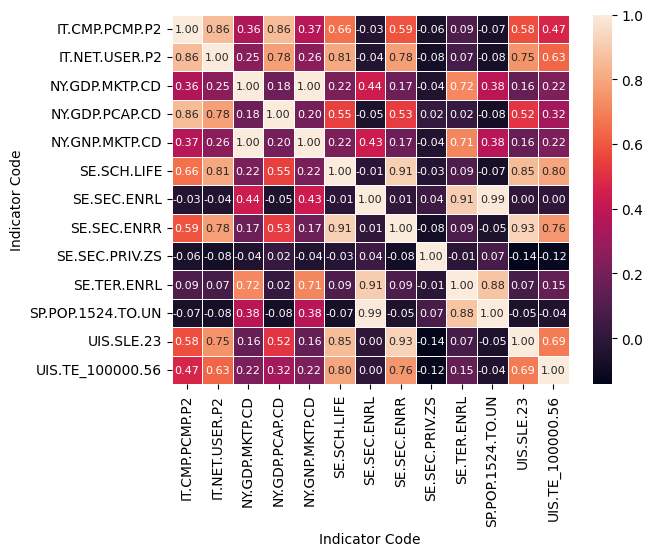

In [94]:
sb.heatmap(pearson_tab, annot=True, fmt=".2f", linewidth=.5, annot_kws={"size": 8})

<Axes: xlabel='Indicator Code', ylabel='Indicator Code'>

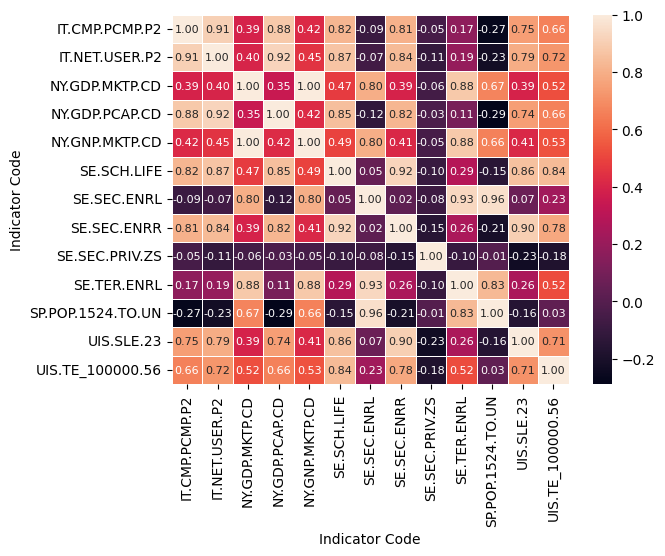

In [95]:
sb.heatmap(spearman_tab, annot=True, fmt=".2f", linewidth=.5, annot_kws={"size": 8})

## **Supression des indicateurs trop corrélés**

In [97]:
new_data_indic_choisis

Indicator Code,IT.CMP.PCMP.P2,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GDP.PCAP.CD,NY.GNP.MKTP.CD,SE.SCH.LIFE,SE.SEC.ENRL,SE.SEC.ENRR,SE.SEC.PRIV.ZS,SE.TER.ENRL,SP.POP.1524.TO.UN,UIS.SLE.23,UIS.TE_100000.56
Country Name,,,,,,,,,,,,,
Afghanistan,0.3660,3.5647,12218642235.0175,414.7556,12319419477.1565,8.8872,1550561.7857,38.8795,1.9681,101884.4000,5532620.1250,2.2640,350.7124
Albania,2.1916,29.1497,9665218788.4674,3288.0174,9702366498.9333,12.6713,372400.1875,83.2348,6.6461,97111.6875,580855.2500,6.2173,3143.8382
Algeria,0.7930,13.6698,135392482448.7874,3747.4558,132198162948.8272,12.5515,3782396.5833,79.2815,0.1156,968926.9286,7125303.0625,5.1212,2676.1132
American Samoa,NaN,NaN,580533333.3333,10230.6809,NaN,NaN,NaN,NaN,NaN,1607.0000,NaN,NaN,NaN
Andorra,NaN,62.5838,2985139319.2289,37652.5429,NaN,NaN,3865.6429,NaN,3.1271,413.4000,7739.8571,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Virgin Islands (U.S.),2.6990,33.4383,4039000000.0000,37927.7117,NaN,NaN,NaN,NaN,NaN,2488.0000,NaN,NaN,NaN
West Bank and Gaza,4.2922,27.5007,7722311764.7059,2023.9475,8439020852.9412,12.7136,654290.2500,85.0826,5.1837,160284.6875,807075.6250,6.7774,4007.0086
"Yemen, Rep.",1.2363,9.5442,24299395604.4368,1038.0135,22911014911.0406,8.6226,1516735.0000,45.7207,2.6883,228206.7000,4917913.6875,2.7610,1058.6879


In [99]:
indic_supp = [
    "IT.CMP.PCMP.P2",
    "NY.GDP.PCAP.CD",
    "SE.SCH.LIFE",
    "SE.SEC.ENRR",
    "SE.TER.ENRL",
    "SE.SEC.ENRL",
    "UIS.SLE.23"
]

In [101]:
cols_to_drop = new_data_indic_choisis.columns[
    new_data_indic_choisis.columns.str.contains(
        'IT.CMP.PCMP.P2|NY.GDP.PCAP.CD|SE.SCH.LIFE|SE.SEC.ENRR|SE.TER.ENRL|SE.SEC.ENRL|UIS.SLE.23'
    )
]

In [102]:
new_data_indic_choisis.drop(cols_to_drop, axis=1, inplace=True)


## **Suppression des pays ayant des indicateurs avec une ou plusieurs valeurs nulles**

In [126]:
new_data_indic_choisis.dropna(how='any',axis=0, inplace = True)

## **Normaliser les grandes valeurs pour une visualisation plus claire**

In [165]:
new_data_indic_choisis["LOG_NY.GDP.MKTP.CD"] = np.log10(new_data_indic_choisis["NY.GDP.MKTP.CD"])
new_data_indic_choisis["LOG_SP.POP.1524.TO.UN"] = np.log10(new_data_indic_choisis["SP.POP.1524.TO.UN"])
new_data_indic_choisis["LOG_NY.GNP.MKTP.CD"] = np.log10(new_data_indic_choisis["NY.GNP.MKTP.CD"])

In [166]:
new_data_indic_choisis

Indicator Code,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GNP.MKTP.CD,SE.SEC.PRIV.ZS,SP.POP.1524.TO.UN,UIS.TE_100000.56,LOG_NY.GDP.MKTP.CD,LOG_SP.POP.1524.TO.UN,LOG_NY.GNP.MKTP.CD
Country Name,,,,,,,,,
Afghanistan,3.5647,12218642235.0175,12319419477.1565,1.9681,5532620.1250,350.7124,10.0870,6.7429,10.0906
Albania,29.1497,9665218788.4674,9702366498.9333,6.6461,580855.2500,3143.8382,9.9852,5.7641,9.9869
Algeria,13.6698,135392482448.7874,132198162948.8272,0.1156,7125303.0625,2676.1132,11.1316,6.8528,11.1212
Angola,3.9288,65088637385.6975,58872337397.8022,10.6802,3496905.7500,385.5393,10.8135,6.5437,10.7699
Antigua and Barbuda,39.5033,1124000404.0523,1082529114.2919,18.5530,12980.5000,1441.5812,9.0508,4.1133,9.0344
...,...,...,...,...,...,...,...,...,...
Vanuatu,9.0500,556360707.1626,512457282.4367,17.4891,46771.6250,419.9429,8.7454,4.6700,8.7097
"Venezuela, RB",29.2004,245228638083.9497,241561060651.4040,27.6925,5239756.4375,4851.6478,11.3896,6.7193,11.3830
West Bank and Gaza,27.5007,7722311764.7059,8439020852.9412,5.1837,807075.6250,4007.0086,9.8877,5.9069,9.9263


In [150]:
pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 11.1/11.1 MB 88.8 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- -------

# **Analyse de nos indicateurs restants**

In [138]:
new_data_indic_choisis['IT.NET.USER.P2'].describe()

count   167.0000
mean     28.7484
std      23.5735
min       0.6310
25%       8.5226
50%      24.2550
75%      44.6561
max      86.2753
Name: IT.NET.USER.P2, dtype: float64

In [106]:
import matplotlib.pyplot as plt

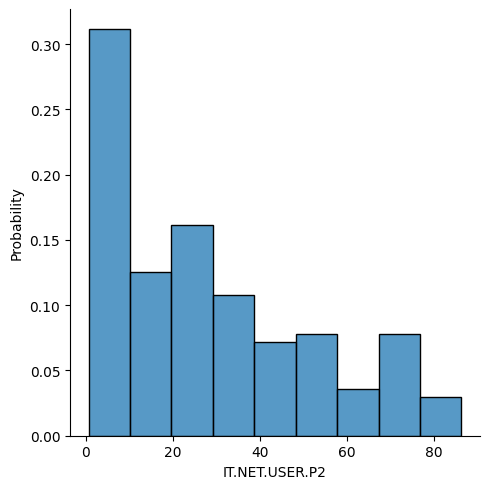

In [139]:

sb.displot(data = new_data_indic_choisis, x="IT.NET.USER.P2", stat = 'probability')

In [108]:
def desc_displot_columns(df):
    for column in df.columns:
       print(f"\n--- {column} ---")
       print(df[column].describe())
       print(sb.displot(data = df, x=column))


--- IT.NET.USER.P2 ---
count   167.0000
mean     28.7484
std      23.5735
min       0.6310
25%       8.5226
50%      24.2550
75%      44.6561
max      86.2753
Name: IT.NET.USER.P2, dtype: float64

--- NY.GDP.MKTP.CD ---
count              167.0000
mean      337756129349.0427
std      1297402822564.6343
min          154038011.7647
25%         6204518133.8499
50%        24924590281.7645
75%       174196297510.4684
max     14335391000000.0000
Name: NY.GDP.MKTP.CD, dtype: float64

--- NY.GNP.MKTP.CD ---
count              167.0000
mean      338257087492.6628
std      1314641878843.8726
min          187988723.5294
25%         6234361817.5553
50%        22911014911.0406
75%       175494954832.3327
max     14561323588235.2949
Name: NY.GNP.MKTP.CD, dtype: float64

--- SE.SEC.PRIV.ZS ---
count   167.0000
mean     17.9192
std      18.5856
min       0.0291
25%       4.9136
50%      12.3623
75%      24.8602
max      95.3807
Name: SE.SEC.PRIV.ZS, dtype: float64

--- SP.POP.1524.TO.UN ---
count    

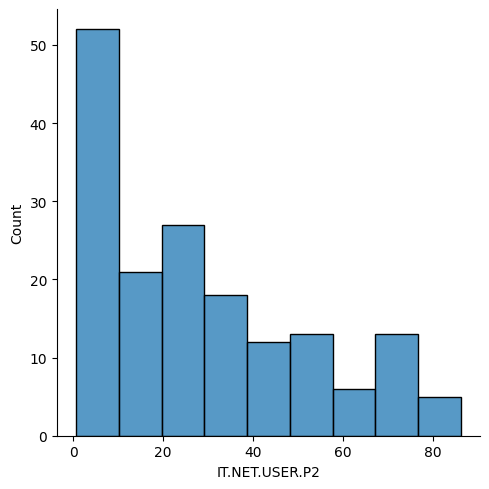

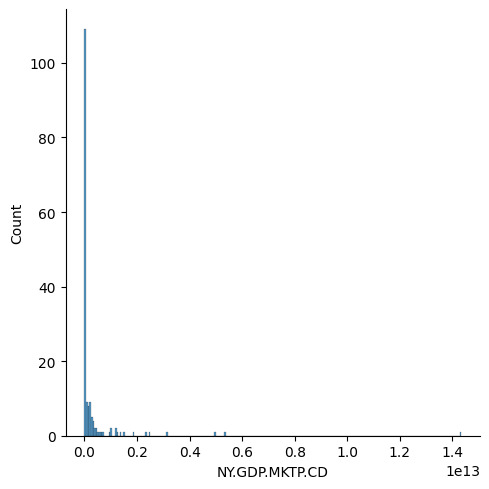

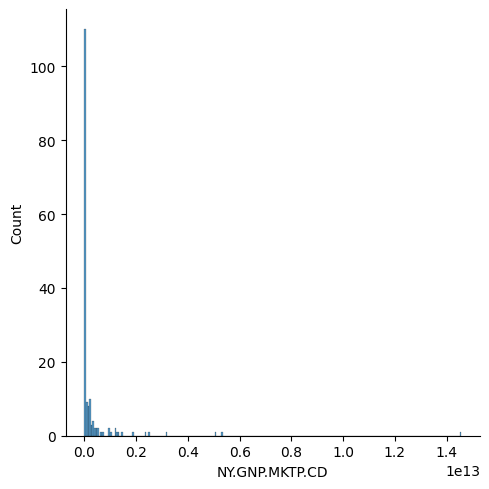

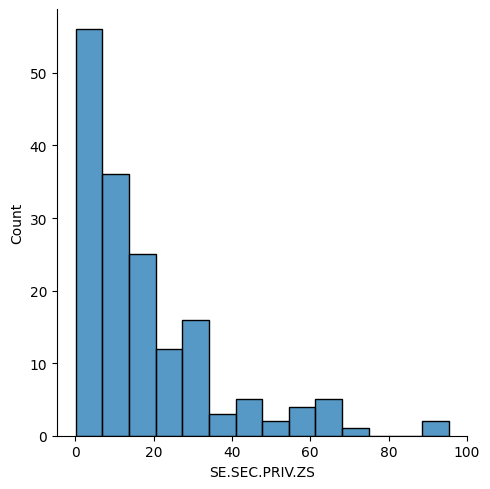

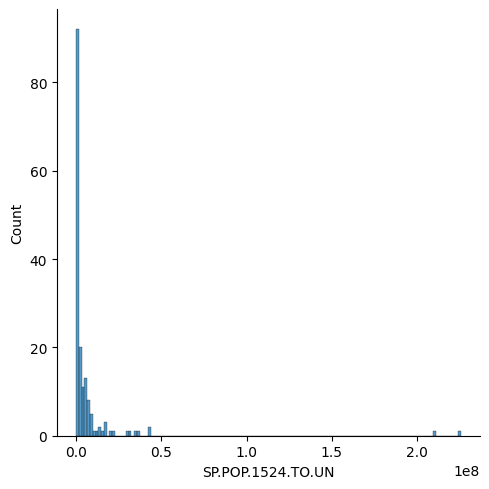

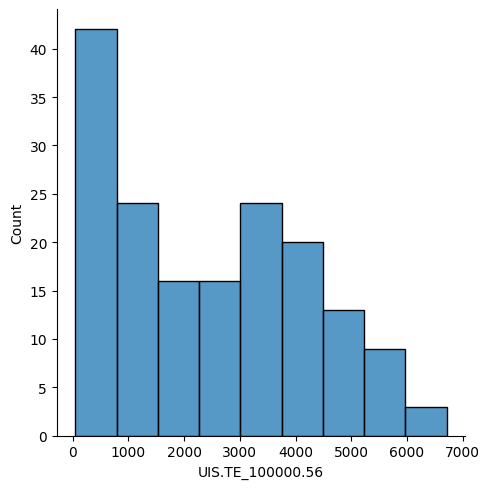

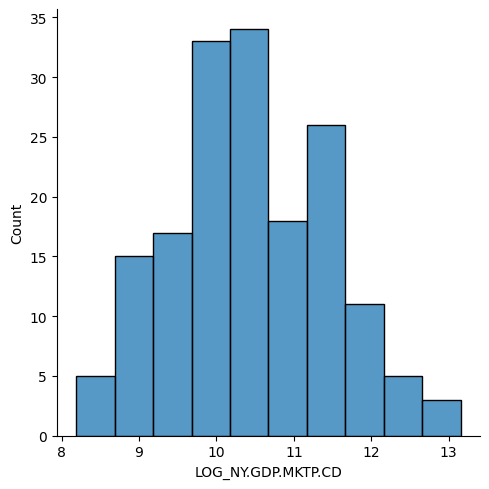

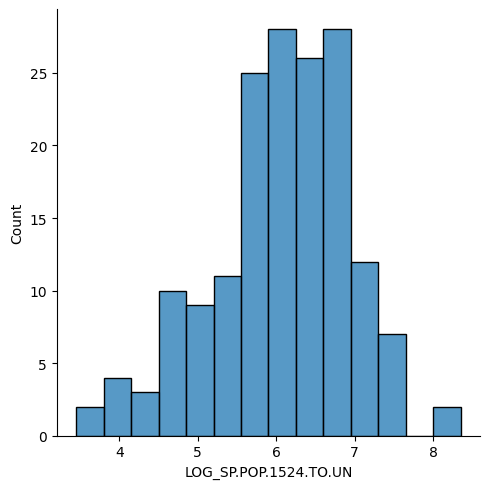

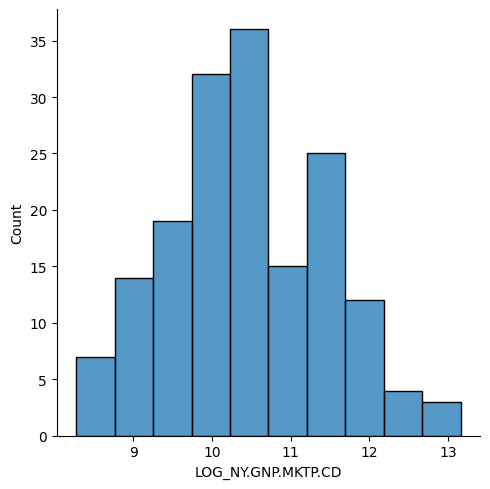

In [167]:
desc_displot_columns(new_data_indic_choisis)

## **Proposition d'une methode quantitative : le top 5 des pays pour chaque indicateur**

In [127]:
new_data_indic_choisis

Indicator Code,IT.NET.USER.P2,NY.GDP.MKTP.CD,NY.GNP.MKTP.CD,SE.SEC.PRIV.ZS,SP.POP.1524.TO.UN,UIS.TE_100000.56
Country Name,,,,,,
Afghanistan,3.5647,12218642235.0175,12319419477.1565,1.9681,5532620.1250,350.7124
Albania,29.1497,9665218788.4674,9702366498.9333,6.6461,580855.2500,3143.8382
Algeria,13.6698,135392482448.7874,132198162948.8272,0.1156,7125303.0625,2676.1132
Angola,3.9288,65088637385.6975,58872337397.8022,10.6802,3496905.7500,385.5393
Antigua and Barbuda,39.5033,1124000404.0523,1082529114.2919,18.5530,12980.5000,1441.5812
...,...,...,...,...,...,...
Vanuatu,9.0500,556360707.1626,512457282.4367,17.4891,46771.6250,419.9429
"Venezuela, RB",29.2004,245228638083.9497,241561060651.4040,27.6925,5239756.4375,4851.6478
West Bank and Gaza,27.5007,7722311764.7059,8439020852.9412,5.1837,807075.6250,4007.0086


In [128]:
new_data_indic_choisis.isnull().mean(axis=1)

Country Name
Afghanistan           0.0000
Albania               0.0000
Algeria               0.0000
Angola                0.0000
Antigua and Barbuda   0.0000
                       ...  
Vanuatu               0.0000
Venezuela, RB         0.0000
West Bank and Gaza    0.0000
Yemen, Rep.           0.0000
Zimbabwe              0.0000
Length: 167, dtype: float64

In [129]:
new_data_indic_choisis['NY.GDP.MKTP.CD'].sort_values(ascending = False)

Country Name
United States           14335391000000.0000
China                    5324852760257.6104
Japan                    4942693353685.7793
Germany                  3117306044205.6665
United Kingdom           2473821124012.8091
                                ...        
Comoros                      458175515.2749
Tonga                        324635739.9648
Palau                        202503829.4118
Sao Tome and Principe        195655493.1740
Marshall Islands             154038011.7647
Name: NY.GDP.MKTP.CD, Length: 167, dtype: float64

**1ère methode**

In [130]:
def top5_country(df):
    for column in df.columns:
       print(f"\n--- {column} ---")
       print(list(df.nlargest(5, [column]).index))

In [168]:
count_list_5 = top5_country(new_data_indic_choisis)
count_list_5


--- IT.NET.USER.P2 ---
['Iceland', 'Norway', 'Sweden', 'Denmark', 'Netherlands']

--- NY.GDP.MKTP.CD ---
['United States', 'China', 'Japan', 'Germany', 'United Kingdom']

--- NY.GNP.MKTP.CD ---
['United States', 'China', 'Japan', 'Germany', 'United Kingdom']

--- SE.SEC.PRIV.ZS ---
['Bangladesh', 'Macao SAR, China', 'Zimbabwe', 'Belize', 'Guatemala']

--- SP.POP.1524.TO.UN ---
['India', 'China', 'United States', 'Indonesia', 'Pakistan']

--- UIS.TE_100000.56 ---
['Korea, Rep.', 'Grenada', 'Libya', 'United States', 'Russian Federation']

--- LOG_NY.GDP.MKTP.CD ---
['United States', 'China', 'Japan', 'Germany', 'United Kingdom']

--- LOG_SP.POP.1524.TO.UN ---
['India', 'China', 'United States', 'Indonesia', 'Pakistan']

--- LOG_NY.GNP.MKTP.CD ---
['United States', 'China', 'Japan', 'Germany', 'United Kingdom']


**2ème methode**

In [132]:
lst1 = [['Iceland', 'Norway', 'Sweden', 'Denmark', 'Netherlands'],
['United States', 'China', 'Japan', 'Germany', 'United Kingdom'],
['United States', 'China', 'Japan', 'Germany', 'United Kingdom'],
['Bangladesh', 'Macao SAR, China', 'Sint Maarten (Dutch part)', 'Aruba', 'Zimbabwe'],
['India', 'China', 'United States', 'Indonesia', 'Pakistan'],
['Korea, Rep.', 'Puerto Rico', 'Grenada', 'Libya', 'United States']]

In [133]:

import collections
counts = collections.Counter(c for l in lst1 for c in l)
print(counts.most_common())

[('United States', 4), ('China', 3), ('Japan', 2), ('Germany', 2), ('United Kingdom', 2), ('Iceland', 1), ('Norway', 1), ('Sweden', 1), ('Denmark', 1), ('Netherlands', 1), ('Bangladesh', 1), ('Macao SAR, China', 1), ('Sint Maarten (Dutch part)', 1), ('Aruba', 1), ('Zimbabwe', 1), ('India', 1), ('Indonesia', 1), ('Pakistan', 1), ('Korea, Rep.', 1), ('Puerto Rico', 1), ('Grenada', 1), ('Libya', 1)]


In [134]:
counts.most_common()

[('United States', 4),
 ('China', 3),
 ('Japan', 2),
 ('Germany', 2),
 ('United Kingdom', 2),
 ('Iceland', 1),
 ('Norway', 1),
 ('Sweden', 1),
 ('Denmark', 1),
 ('Netherlands', 1),
 ('Bangladesh', 1),
 ('Macao SAR, China', 1),
 ('Sint Maarten (Dutch part)', 1),
 ('Aruba', 1),
 ('Zimbabwe', 1),
 ('India', 1),
 ('Indonesia', 1),
 ('Pakistan', 1),
 ('Korea, Rep.', 1),
 ('Puerto Rico', 1),
 ('Grenada', 1),
 ('Libya', 1)]

In [135]:
count_occ = counts.most_common()
df_count_occ = pd.DataFrame(counts.most_common())
df_count_occ.rename(columns={0: 'Country', 1: 'Occurences'}, inplace=True)

df_count_occ

,Country,Occurences
0,United States,4
1,China,3
2,Japan,2
3,Germany,2
4,United Kingdom,2
5,Iceland,1
6,Norway,1
7,Sweden,1
8,Denmark,1
9,Netherlands,1


In [136]:
top5_count_occ = df_count_occ.loc[0:4,:]
top5_count_occ

,Country,Occurences
0,United States,4
1,China,3
2,Japan,2
3,Germany,2
4,United Kingdom,2


#On remarque que les USA et la chine semblent etre présents dans plusieurs top 5

**3ème methode**

In [119]:
top5_by_indicator = {
    col: new_data_indic_choisis[col].nlargest(5).index.tolist()
    for col in new_data_indic_choisis.columns
}


In [120]:
from collections import Counter
top5_flat = [pays for top5 in top5_by_indicator.values() for pays in top5]
top5_counts = Counter(top5_flat)

In [121]:
df_top5 = pd.DataFrame.from_dict(top5_counts, orient='index', columns=["Nombre de top 5"])
df_top5 = df_top5.sort_values(by="Nombre de top 5", ascending=False)

print(df_top5)

                           Nombre de top 5
United States                            4
China                                    3
United Kingdom                           2
Germany                                  2
Japan                                    2
Iceland                                  1
Netherlands                              1
Denmark                                  1
Sweden                                   1
Norway                                   1
Bangladesh                               1
Macao SAR, China                         1
Sint Maarten (Dutch part)                1
Aruba                                    1
Zimbabwe                                 1
India                                    1
Indonesia                                1
Pakistan                                 1
Korea, Rep.                              1
Puerto Rico                              1
Grenada                                  1
Libya                                    1


## **Au vue de nos resultats les pays les intéressants pour notre potentielle ouverture à l'internationale sont les USA et la Chine**